# Notebook 2: Baseline Models — Default Performance and Bayesian Tuning

This notebook trains and evaluates the baseline Random Forest and XGBoost models using the five temporal and weather predictors prepared earlier. It then applies a controlled Bayesian hyperparameter search using only the training and validation partitions.

The final testing partition remains untouched until the best validation configuration has been selected. `LocationID`, borough, zone and pickup time are retained only as evaluation metadata and are not supplied to either model.


## 1. Environment and file locations

The Windows path below points to the `processed_outputs` directory. The optional environment variable is used only when running the notebook in another environment.

Required split files:

- `nyc_yellow_taxi_baseline_train_2025_q1.csv`
- `nyc_yellow_taxi_baseline_validation_2025_q1.csv`
- `nyc_yellow_taxi_baseline_test_2025_q1.csv`


In [2]:
from pathlib import Path
import json
import os
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import norm
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import xgboost
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError("Install XGBoost with: pip install xgboost") from exc

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

WINDOWS_OUTPUTS = Path(
    r"C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs"
)
PROCESSED_OUTPUTS = Path(os.environ.get("NYC_TAXI_PROCESSED_OUTPUTS", WINDOWS_OUTPUTS))
DATA_DIR = PROCESSED_OUTPUTS / "model_datasets"
RESULTS_DIR = PROCESSED_OUTPUTS / "model_results" / "baseline"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "nyc_yellow_taxi_baseline_train_2025_q1.csv"
VALIDATION_PATH = DATA_DIR / "nyc_yellow_taxi_baseline_validation_2025_q1.csv"
TEST_PATH = DATA_DIR / "nyc_yellow_taxi_baseline_test_2025_q1.csv"

RANDOM_STATE = 42
print(f"Data directory: {DATA_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"XGBoost version: {xgboost.__version__}")


Data directory: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\model_datasets
Results directory: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\model_results\baseline
XGBoost version: 3.1.1


## 2. Load and verify the split datasets

This section performs only essential integrity checks. It does not repeat the splitting process. The same predictor columns are used in training, validation and testing so that the models receive an identical input structure in every partition.


In [3]:
# Confirm that Notebook 1 produced every required split file.
required_files = [TRAIN_PATH, VALIDATION_PATH, TEST_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError("Missing split file(s):\n" + "\n".join(missing_files))

# Load the three prepared baseline partitions.
train_df = pd.read_csv(TRAIN_PATH, parse_dates=["pickup_hour"])
validation_df = pd.read_csv(VALIDATION_PATH, parse_dates=["pickup_hour"])
test_df = pd.read_csv(TEST_PATH, parse_dates=["pickup_hour"])

BASELINE_FEATURES = [
    "hour",
    "day_of_week",
    "month",
    "temperature_f",
    "precipitation_in",
]
TARGET = "pickup_count"
METADATA_COLUMNS = ["LocationID", "borough", "zone", "pickup_hour"]
REQUIRED_COLUMNS = METADATA_COLUMNS + [TARGET] + BASELINE_FEATURES

# Verify columns, missing values and duplicated zone-hour rows.
for name, frame in {
    "Training": train_df,
    "Validation": validation_df,
    "Testing": test_df,
}.items():
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    assert not missing_columns, f"{name} is missing: {missing_columns}"
    assert frame[REQUIRED_COLUMNS].isna().sum().sum() == 0
    assert not frame.duplicated(["LocationID", "pickup_hour"]).any()

split_check = pd.DataFrame([
    {
        "Partition": name,
        "Rows": len(frame),
        "Zones": frame["LocationID"].nunique(),
        "Start": frame["pickup_hour"].min(),
        "End": frame["pickup_hour"].max(),
    }
    for name, frame in {
        "Training": train_df,
        "Validation": validation_df,
        "Testing": test_df,
    }.items()
])
display(split_check)


,Partition,Rows,Zones,Start,End
0,Training,335405,259,2025-01-01 00:00:00,2025-02-23 22:00:00
1,Validation,111888,259,2025-02-23 23:00:00,2025-03-13 23:00:00
2,Testing,111888,259,2025-03-14 00:00:00,2025-03-31 23:00:00


In [4]:
# Prepare predictors and target values without using LocationID as a predictor.
X_train = train_df[BASELINE_FEATURES]
y_train = train_df[TARGET]

X_validation = validation_df[BASELINE_FEATURES]
y_validation = validation_df[TARGET]

X_test = test_df[BASELINE_FEATURES]
y_test = test_df[TARGET]

# Combine training and validation only after tuning has selected the best configuration.
X_train_validation = pd.concat([X_train, X_validation], ignore_index=True)
y_train_validation = pd.concat([y_train, y_validation], ignore_index=True)

matrix_summary = pd.DataFrame({
    "Partition": ["Training", "Validation", "Testing"],
    "Predictor shape": [str(X_train.shape), str(X_validation.shape), str(X_test.shape)],
    "Target shape": [str(y_train.shape), str(y_validation.shape), str(y_test.shape)],
})
display(matrix_summary)
print("Model predictors:", BASELINE_FEATURES)
print("Evaluation metadata:", METADATA_COLUMNS)


,Partition,Predictor shape,Target shape
0,Training,"(335405, 5)","(335405,)"
1,Validation,"(111888, 5)","(111888,)"
2,Testing,"(111888, 5)","(111888,)"


Model predictors: ['hour', 'day_of_week', 'month', 'temperature_f', 'precipitation_in']
Evaluation metadata: ['LocationID', 'borough', 'zone', 'pickup_hour']


## 3. Evaluation functions and default models

Validation RMSE is the single optimisation objective. MAE and \(R^2\) are retained as complementary evaluation measures. The default models provide the reference point needed to determine whether tuning produces a genuine improvement.


In [5]:
def calculate_metrics(y_true, y_pred):
    # Return the three regression metrics used in this study.
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


def build_model(algorithm, parameters=None):
    # Create one Random Forest or XGBoost model.
    parameters = {} if parameters is None else dict(parameters)

    if algorithm == "Random Forest":
        return RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **parameters,
        )

    return XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **parameters,
    )


In [6]:
# Fit the default models on training data and evaluate them on validation data.
default_validation_rows = []
default_development_models = {}

for algorithm in ["Random Forest", "XGBoost"]:
    model = build_model(algorithm)
    started = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started
    predictions = model.predict(X_validation)
    metrics = calculate_metrics(y_validation, predictions)

    default_development_models[algorithm] = model
    default_validation_rows.append({
        "Algorithm": algorithm,
        "Configuration": "Default",
        **metrics,
        "Fit seconds": fit_seconds,
    })

default_validation_metrics = pd.DataFrame(default_validation_rows)
display(default_validation_metrics.round(4))


,Algorithm,Configuration,RMSE,MAE,R2,Fit seconds
0,Random Forest,Default,56.7443,28.1821,0.0302,36.8149
1,XGBoost,Default,56.7824,28.5934,0.0289,3.8517


## 4. Controlled Bayesian optimisation

A Gaussian-process Bayesian optimiser is used so that the search remains self-contained and reproducible. The first 10 trials explore randomly. Later trials use expected improvement to concentrate on promising combinations.

The search follows the same stopping rule for both algorithms:

- minimum completed trials: 15;
- patience: 8 consecutive trials without at least 0.1% improvement;
- maximum trials: 30;
- selection metric: validation RMSE.

The testing partition is not accessed during this process.


In [7]:
# Define focused search spaces that control complexity and computational cost.
RF_SPACE = {
    "n_estimators": {"kind": "int", "low": 80, "high": 300},
    "max_depth": {"kind": "int", "low": 4, "high": 18},
    "min_samples_split": {"kind": "int", "low": 2, "high": 30},
    "min_samples_leaf": {"kind": "logint", "low": 1, "high": 1200},
    "max_features": {"kind": "float", "low": 0.50, "high": 1.00},
}

XGB_SPACE = {
    "n_estimators": {"kind": "int", "low": 80, "high": 350},
    "learning_rate": {"kind": "logfloat", "low": 0.01, "high": 0.20},
    "max_depth": {"kind": "int", "low": 2, "high": 8},
    "min_child_weight": {"kind": "logfloat", "low": 1.0, "high": 500.0},
    "subsample": {"kind": "float", "low": 0.60, "high": 1.00},
    "colsample_bytree": {"kind": "float", "low": 0.60, "high": 1.00},
}

search_space_table = pd.DataFrame([
    {
        "Algorithm": algorithm,
        "Hyperparameter": parameter,
        "Scale": settings["kind"],
        "Lower bound": settings["low"],
        "Upper bound": settings["high"],
    }
    for algorithm, space in [("Random Forest", RF_SPACE), ("XGBoost", XGB_SPACE)]
    for parameter, settings in space.items()
])
display(search_space_table)


,Algorithm,Hyperparameter,Scale,Lower bound,Upper bound
0,Random Forest,n_estimators,int,80.00,300.0
1,Random Forest,max_depth,int,4.00,18.0
2,Random Forest,min_samples_split,int,2.00,30.0
3,Random Forest,min_samples_leaf,logint,1.00,1200.0
4,Random Forest,max_features,float,0.50,1.0
5,XGBoost,n_estimators,int,80.00,350.0
6,XGBoost,learning_rate,logfloat,0.01,0.2
7,XGBoost,max_depth,int,2.00,8.0
8,XGBoost,min_child_weight,logfloat,1.00,500.0
9,XGBoost,subsample,float,0.60,1.0


In [8]:
def sample_configuration(space, rng):
    # Draw one configuration from a search space.
    configuration = {}
    for name, settings in space.items():
        low, high, kind = settings["low"], settings["high"], settings["kind"]
        if kind == "int":
            value = int(rng.integers(low, high + 1))
        elif kind == "logint":
            value = int(np.clip(round(np.exp(rng.uniform(np.log(low), np.log(high)))), low, high))
        elif kind == "logfloat":
            value = float(np.exp(rng.uniform(np.log(low), np.log(high))))
        else:
            value = float(rng.uniform(low, high))
        configuration[name] = value
    return configuration


def encode_configuration(configuration, space):
    # Convert a configuration to a zero-to-one numerical vector.
    encoded = []
    for name, settings in space.items():
        value, low, high = configuration[name], settings["low"], settings["high"]
        if settings["kind"].startswith("log"):
            value, low, high = np.log(value), np.log(low), np.log(high)
        encoded.append((value - low) / (high - low))
    return np.asarray(encoded, dtype=float)


def configuration_key(configuration):
    # Create a stable key used to avoid duplicated trials.
    return tuple((name, round(float(value), 8)) for name, value in sorted(configuration.items()))


def propose_bayesian_configuration(space, completed_trials, rng, candidate_count=1000):
    # Select the candidate with the highest expected improvement.
    tried_keys = {configuration_key(row["Parameters"]) for row in completed_trials}
    candidates = []
    while len(candidates) < candidate_count:
        candidate = sample_configuration(space, rng)
        if configuration_key(candidate) not in tried_keys:
            candidates.append(candidate)

    X_history = np.vstack([
        encode_configuration(row["Parameters"], space) for row in completed_trials
    ])
    y_history = np.asarray([row["Validation RMSE"] for row in completed_trials])
    X_candidates = np.vstack([
        encode_configuration(candidate, space) for candidate in candidates
    ])

    kernel = ConstantKernel(1.0) * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(1e-5)
    surrogate = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        random_state=RANDOM_STATE,
        n_restarts_optimizer=1,
    )
    surrogate.fit(X_history, y_history)
    mean, std = surrogate.predict(X_candidates, return_std=True)

    improvement = y_history.min() - mean - 0.01
    z_score = np.divide(improvement, std, out=np.zeros_like(improvement), where=std > 0)
    expected_improvement = improvement * norm.cdf(z_score) + std * norm.pdf(z_score)
    expected_improvement[std == 0] = 0

    return candidates[int(np.argmax(expected_improvement))]


def run_bayesian_search(
    algorithm,
    space,
    default_validation_rmse,
    minimum_trials=15,
    patience=8,
    maximum_trials=30,
    minimum_relative_improvement=0.001,
    warmup_trials=10,
):
    # Optimise validation RMSE and stop after sustained non-improvement.
    rng = np.random.default_rng(RANDOM_STATE)
    records = []
    selected_rmse = np.inf
    selected_parameters = None
    meaningful_reference = np.inf
    wait = 0

    for trial_number in range(1, maximum_trials + 1):
        phase = "Random warm-up" if trial_number <= warmup_trials else "Bayesian-guided"
        if trial_number <= warmup_trials:
            parameters = sample_configuration(space, rng)
        else:
            parameters = propose_bayesian_configuration(space, records, rng)

        model = build_model(algorithm, parameters)
        started = time.perf_counter()
        model.fit(X_train, y_train)
        validation_predictions = model.predict(X_validation)
        fit_seconds = time.perf_counter() - started
        validation_rmse = calculate_metrics(y_validation, validation_predictions)["RMSE"]

        if validation_rmse < selected_rmse:
            selected_rmse = validation_rmse
            selected_parameters = dict(parameters)

        if validation_rmse < meaningful_reference * (1 - minimum_relative_improvement):
            meaningful_reference = validation_rmse
            wait = 0
        elif trial_number >= minimum_trials:
            wait += 1

        records.append({
            "Trial": trial_number,
            "Phase": phase,
            "Validation RMSE": validation_rmse,
            "Fit seconds": fit_seconds,
            "Parameters": dict(parameters),
        })

        print(
            f"{algorithm} trial {trial_number:02d}: "
            f"RMSE={validation_rmse:.4f}, best={selected_rmse:.4f}, wait={wait}"
        )

        if trial_number >= minimum_trials and wait >= patience:
            print(f"Early stopping reached at trial {trial_number}.")
            break

    trial_table = pd.DataFrame([
        {
            "Trial": row["Trial"],
            "Phase": row["Phase"],
            "Validation RMSE": row["Validation RMSE"],
            "Fit seconds": row["Fit seconds"],
            **row["Parameters"],
        }
        for row in records
    ])
    trial_table["Best-so-far RMSE"] = trial_table["Validation RMSE"].cummin()
    best_trial = int(trial_table.loc[trial_table["Validation RMSE"].idxmin(), "Trial"])

    return {
        "algorithm": algorithm,
        "default_validation_rmse": default_validation_rmse,
        "best_parameters": selected_parameters,
        "best_validation_rmse": selected_rmse,
        "best_trial": best_trial,
        "stopping_trial": int(trial_table["Trial"].max()),
        "trials": trial_table,
    }


## 5. Random Forest Bayesian tuning

Each Random Forest trial is fitted on the training partition and scored on the validation partition. The convergence chart separates the initial random exploration from the later Bayesian-guided search.


In [9]:
# Run the controlled Random Forest Bayesian search.
rf_default_validation_rmse = default_validation_metrics.loc[
    default_validation_metrics["Algorithm"].eq("Random Forest"), "RMSE"
].iloc[0]

rf_study = run_bayesian_search(
    algorithm="Random Forest",
    space=RF_SPACE,
    default_validation_rmse=rf_default_validation_rmse,
)

display(rf_study["trials"].round(4))
print("Best Random Forest trial:", rf_study["best_trial"])
print("Best Random Forest parameters:", rf_study["best_parameters"])


Random Forest trial 01: RMSE=56.6504, best=56.6504, wait=0
Random Forest trial 02: RMSE=56.6411, best=56.6411, wait=0
Random Forest trial 03: RMSE=56.6640, best=56.6411, wait=0
Random Forest trial 04: RMSE=56.7051, best=56.6411, wait=0
Random Forest trial 05: RMSE=56.6682, best=56.6411, wait=0
Random Forest trial 06: RMSE=56.7023, best=56.6411, wait=0
Random Forest trial 07: RMSE=56.6522, best=56.6411, wait=0
Random Forest trial 08: RMSE=56.6473, best=56.6411, wait=0
Random Forest trial 09: RMSE=56.6926, best=56.6411, wait=0
Random Forest trial 10: RMSE=56.6726, best=56.6411, wait=0
Random Forest trial 11: RMSE=56.6978, best=56.6411, wait=0
Random Forest trial 12: RMSE=56.6643, best=56.6411, wait=0
Random Forest trial 13: RMSE=56.6453, best=56.6411, wait=0
Random Forest trial 14: RMSE=56.6570, best=56.6411, wait=0
Random Forest trial 15: RMSE=56.6304, best=56.6304, wait=1
Random Forest trial 16: RMSE=56.6329, best=56.6304, wait=2
Random Forest trial 17: RMSE=56.6280, best=56.6280, wait

,Trial,Phase,Validation RMSE,Fit seconds,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,Best-so-far RMSE
0,1,Random warm-up,56.6504,19.3423,99,15,20,440,0.8487,56.6504
1,2,Random warm-up,56.6411,33.7026,176,7,4,1010,0.8806,56.6411
2,3,Random warm-up,56.6640,59.7451,238,15,16,24,0.6854,56.6411
3,4,Random warm-up,56.7051,25.1699,108,6,28,96,0.9114,56.6411
4,5,Random warm-up,56.6682,47.4898,200,10,15,51,0.5319,56.6411
5,6,Random warm-up,56.7023,37.7587,130,16,26,88,0.8790,56.6411
6,7,Random warm-up,56.6522,47.5003,234,9,3,562,0.8892,56.6411
7,8,Random warm-up,56.6473,32.2388,294,15,7,27,0.5219,56.6411
8,9,Random warm-up,56.6926,21.7741,200,6,23,196,0.9838,56.6411
9,10,Random warm-up,56.6726,34.4338,230,10,11,14,0.7348,56.6411


Best Random Forest trial: 17
Best Random Forest parameters: {'n_estimators': 171, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 955, 'max_features': 0.9219517844408703}


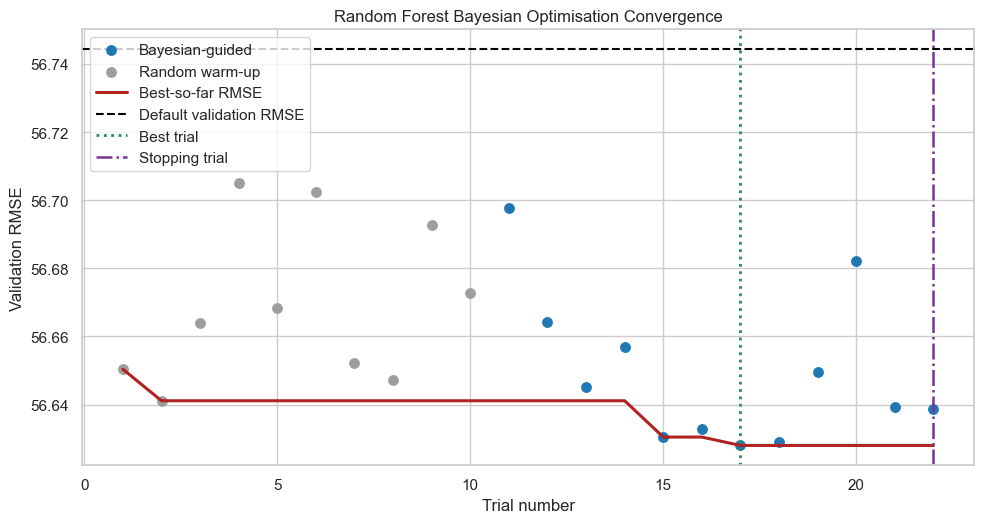

In [10]:
# Plot Random Forest optimisation convergence.
rf_trials = rf_study["trials"]
phase_colours = {"Random warm-up": "#9e9e9e", "Bayesian-guided": "#1f77b4"}

fig, ax = plt.subplots(figsize=(10, 5.4))
for phase, group in rf_trials.groupby("Phase"):
    ax.scatter(group["Trial"], group["Validation RMSE"], color=phase_colours[phase], label=phase, s=46)
ax.plot(rf_trials["Trial"], rf_trials["Best-so-far RMSE"], color="#b22222", linewidth=2.2, label="Best-so-far RMSE")
ax.axhline(rf_study["default_validation_rmse"], color="black", linestyle="--", label="Default validation RMSE")
ax.axvline(rf_study["best_trial"], color="#2e8b57", linestyle=":", linewidth=2, label="Best trial")
ax.axvline(rf_study["stopping_trial"], color="#7b3294", linestyle="-.", linewidth=1.8, label="Stopping trial")
ax.set(title="Random Forest Bayesian Optimisation Convergence", xlabel="Trial number", ylabel="Validation RMSE")
ax.legend()
plt.tight_layout()
plt.show()


,Hyperparameter,Relative importance
3,min_samples_leaf,0.5336
1,max_depth,0.2243
2,min_samples_split,0.1656
4,max_features,0.0467
0,n_estimators,0.0297


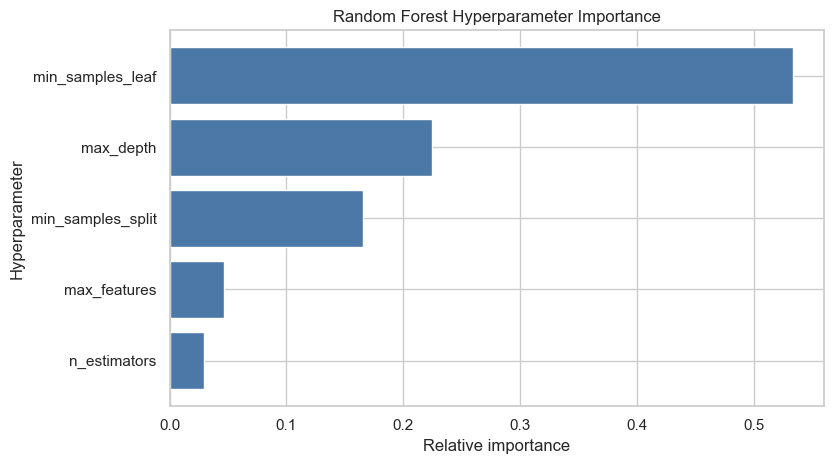

In [11]:
def calculate_search_parameter_importance(trial_table, parameter_names):
    # Estimate exploratory importance using a surrogate and repeated permutation.
    X_trials = trial_table[parameter_names]
    y_trials = trial_table["Validation RMSE"]
    surrogate = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    surrogate.fit(X_trials, y_trials)
    result = permutation_importance(
        surrogate,
        X_trials,
        y_trials,
        scoring="neg_root_mean_squared_error",
        n_repeats=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    positive = np.maximum(result.importances_mean, 0)
    relative = positive / positive.sum() if positive.sum() > 0 else positive
    return pd.DataFrame({
        "Hyperparameter": parameter_names,
        "Relative importance": relative,
    }).sort_values("Relative importance", ascending=True)


# Estimate and plot Random Forest hyperparameter importance.
rf_parameter_importance = calculate_search_parameter_importance(
    rf_trials,
    list(RF_SPACE),
)
display(rf_parameter_importance.sort_values("Relative importance", ascending=False).round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(rf_parameter_importance["Hyperparameter"], rf_parameter_importance["Relative importance"], color="#4c78a8")
ax.set(title="Random Forest Hyperparameter Importance", xlabel="Relative importance", ylabel="Hyperparameter")
plt.tight_layout()
plt.show()


## 6. XGBoost Bayesian tuning

The same training partition, validation partition, objective metric and stopping rule are used for XGBoost. This keeps the comparison controlled even if the two searches stop after different numbers of trials.


In [12]:
# Run the controlled XGBoost Bayesian search.
xgb_default_validation_rmse = default_validation_metrics.loc[
    default_validation_metrics["Algorithm"].eq("XGBoost"), "RMSE"
].iloc[0]

xgb_study = run_bayesian_search(
    algorithm="XGBoost",
    space=XGB_SPACE,
    default_validation_rmse=xgb_default_validation_rmse,
)

display(xgb_study["trials"].round(4))
print("Best XGBoost trial:", xgb_study["best_trial"])
print("Best XGBoost parameters:", xgb_study["best_parameters"])


XGBoost trial 01: RMSE=56.8787, best=56.8787, wait=0
XGBoost trial 02: RMSE=56.8554, best=56.8554, wait=0
XGBoost trial 03: RMSE=56.7790, best=56.7790, wait=0
XGBoost trial 04: RMSE=56.6712, best=56.6712, wait=0
XGBoost trial 05: RMSE=56.7975, best=56.6712, wait=0
XGBoost trial 06: RMSE=56.6663, best=56.6663, wait=0
XGBoost trial 07: RMSE=56.9567, best=56.6663, wait=0
XGBoost trial 08: RMSE=56.6907, best=56.6663, wait=0
XGBoost trial 09: RMSE=56.8077, best=56.6663, wait=0
XGBoost trial 10: RMSE=56.8362, best=56.6663, wait=0
XGBoost trial 11: RMSE=56.7458, best=56.6663, wait=0
XGBoost trial 12: RMSE=56.6681, best=56.6663, wait=0
XGBoost trial 13: RMSE=56.6932, best=56.6663, wait=0
XGBoost trial 14: RMSE=56.6706, best=56.6663, wait=0
XGBoost trial 15: RMSE=56.7269, best=56.6663, wait=1
XGBoost trial 16: RMSE=56.7008, best=56.6663, wait=2
XGBoost trial 17: RMSE=56.7914, best=56.6663, wait=3
XGBoost trial 18: RMSE=56.7451, best=56.6663, wait=4
XGBoost trial 19: RMSE=56.6655, best=56.6655, 

,Trial,Phase,Validation RMSE,Fit seconds,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,Best-so-far RMSE
0,1,Random warm-up,56.8787,5.7010,104,0.0372,7,207.6491,0.8789,0.6377,56.8787
1,2,Random warm-up,56.8554,10.5402,222,0.0978,8,132.3013,0.6512,0.7802,56.8554
2,3,Random warm-up,56.7790,8.0701,215,0.1606,4,54.6730,0.9291,0.7774,56.7790
3,4,Random warm-up,56.6712,6.4846,202,0.0527,3,1.4868,0.9311,0.8527,56.6712
4,5,Random warm-up,56.7975,5.1923,124,0.0289,7,416.7589,0.9572,0.9114,56.6712
5,6,Random warm-up,56.6663,6.0367,285,0.0405,3,1.3129,0.6617,0.8732,56.6663
6,7,Random warm-up,56.9567,11.0628,330,0.1815,7,7.5752,0.7482,0.7878,56.6663
7,8,Random warm-up,56.6907,11.3291,295,0.0148,3,19.2271,0.6908,0.8679,56.6663
8,9,Random warm-up,56.8077,11.1211,334,0.1212,5,77.6237,0.7249,0.9329,56.6663
9,10,Random warm-up,56.8362,7.1231,197,0.0319,7,6.0005,0.8730,0.6559,56.6663


Best XGBoost trial: 19
Best XGBoost parameters: {'n_estimators': 334, 'learning_rate': 0.02099076935447341, 'max_depth': 3, 'min_child_weight': 7.253850765006534, 'subsample': 0.6037799884270122, 'colsample_bytree': 0.9268223018124464}


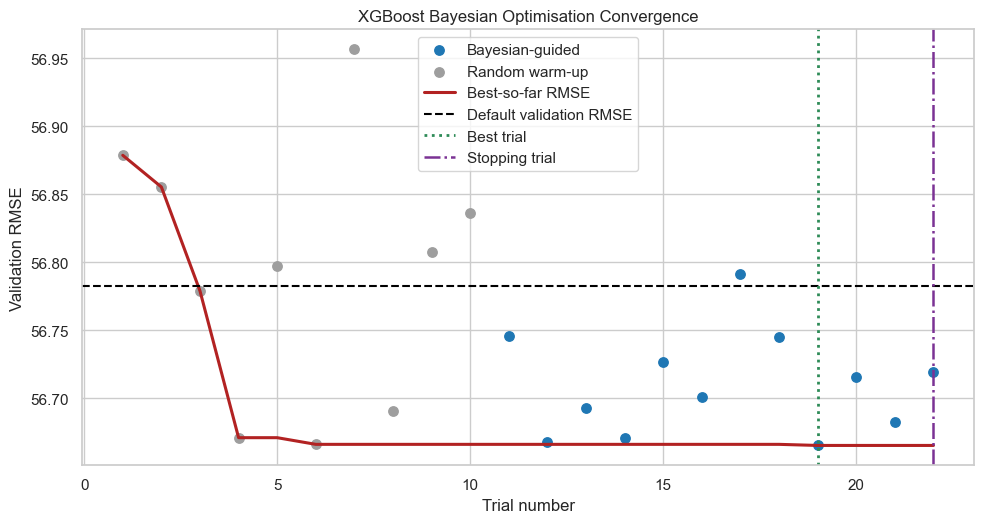

In [13]:
# Plot XGBoost optimisation convergence.
xgb_trials = xgb_study["trials"]

fig, ax = plt.subplots(figsize=(10, 5.4))
for phase, group in xgb_trials.groupby("Phase"):
    ax.scatter(group["Trial"], group["Validation RMSE"], color=phase_colours[phase], label=phase, s=46)
ax.plot(xgb_trials["Trial"], xgb_trials["Best-so-far RMSE"], color="#b22222", linewidth=2.2, label="Best-so-far RMSE")
ax.axhline(xgb_study["default_validation_rmse"], color="black", linestyle="--", label="Default validation RMSE")
ax.axvline(xgb_study["best_trial"], color="#2e8b57", linestyle=":", linewidth=2, label="Best trial")
ax.axvline(xgb_study["stopping_trial"], color="#7b3294", linestyle="-.", linewidth=1.8, label="Stopping trial")
ax.set(title="XGBoost Bayesian Optimisation Convergence", xlabel="Trial number", ylabel="Validation RMSE")
ax.legend()
plt.tight_layout()
plt.show()


,Hyperparameter,Relative importance
2,max_depth,0.6917
5,colsample_bytree,0.1744
3,min_child_weight,0.0411
4,subsample,0.0362
1,learning_rate,0.0362
0,n_estimators,0.0204


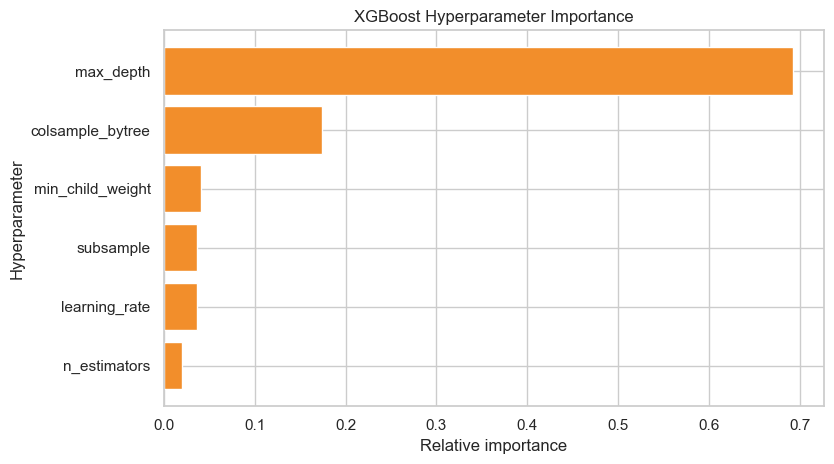

In [14]:
# Estimate and plot XGBoost hyperparameter importance.
xgb_parameter_importance = calculate_search_parameter_importance(
    xgb_trials,
    list(XGB_SPACE),
)
display(xgb_parameter_importance.sort_values("Relative importance", ascending=False).round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(xgb_parameter_importance["Hyperparameter"], xgb_parameter_importance["Relative importance"], color="#f28e2b")
ax.set(title="XGBoost Hyperparameter Importance", xlabel="Relative importance", ylabel="Hyperparameter")
plt.tight_layout()
plt.show()


## 7. Selected validation configurations

The best trial is the configuration with the lowest validation RMSE. The selected parameters are fixed before the testing partition is opened.


In [15]:
# Summarise the selected validation configurations.
selected_configuration_summary = pd.DataFrame([
    {
        "Algorithm": "Random Forest",
        "Default validation RMSE": rf_study["default_validation_rmse"],
        "Best validation RMSE": rf_study["best_validation_rmse"],
        "Best trial": rf_study["best_trial"],
        "Stopping trial": rf_study["stopping_trial"],
    },
    {
        "Algorithm": "XGBoost",
        "Default validation RMSE": xgb_study["default_validation_rmse"],
        "Best validation RMSE": xgb_study["best_validation_rmse"],
        "Best trial": xgb_study["best_trial"],
        "Stopping trial": xgb_study["stopping_trial"],
    },
])
selected_configuration_summary["Validation RMSE reduction (%)"] = (
    (selected_configuration_summary["Default validation RMSE"] - selected_configuration_summary["Best validation RMSE"])
    / selected_configuration_summary["Default validation RMSE"] * 100
)
display(selected_configuration_summary.round(4))


,Algorithm,Default validation RMSE,Best validation RMSE,Best trial,Stopping trial,Validation RMSE reduction (%)
0,Random Forest,56.7443,56.6280,17,22,0.2051
1,XGBoost,56.7824,56.6655,19,22,0.2059


## 8. Final refit and untouched testing evaluation

Four final models are fitted using the combined training and validation data: default and tuned Random Forest, and default and tuned XGBoost. The testing partition is evaluated once to measure generalisation.


In [16]:
# Fit the four final baseline models and generate untouched test predictions.
final_model_definitions = {
    "Random Forest (Default)": ("Random Forest", None),
    "Random Forest (Tuned)": ("Random Forest", rf_study["best_parameters"]),
    "XGBoost (Default)": ("XGBoost", None),
    "XGBoost (Tuned)": ("XGBoost", xgb_study["best_parameters"]),
}

final_models = {}
test_prediction_columns = {}
test_metric_rows = []

for model_name, (algorithm, parameters) in final_model_definitions.items():
    model = build_model(algorithm, parameters)
    started = time.perf_counter()
    model.fit(X_train_validation, y_train_validation)
    fit_seconds = time.perf_counter() - started
    predictions = np.clip(model.predict(X_test), 0, None)
    metrics = calculate_metrics(y_test, predictions)

    final_models[model_name] = model
    test_prediction_columns[model_name] = predictions
    test_metric_rows.append({
        "Model": model_name,
        **metrics,
        "Fit seconds": fit_seconds,
    })

test_metrics = pd.DataFrame(test_metric_rows)
display(test_metrics.round(4))


,Model,RMSE,MAE,R2,Fit seconds
0,Random Forest (Default),54.6348,28.2677,0.0345,44.6389
1,Random Forest (Tuned),54.6256,28.2422,0.0349,61.9182
2,XGBoost (Default),54.6276,28.3391,0.0348,2.6634
3,XGBoost (Tuned),54.6447,28.3933,0.0342,9.8422


In [17]:
# Calculate test-set improvements from default to tuned models.
improvement_rows = []
for algorithm in ["Random Forest", "XGBoost"]:
    default_row = test_metrics.loc[test_metrics["Model"].eq(f"{algorithm} (Default)")].iloc[0]
    tuned_row = test_metrics.loc[test_metrics["Model"].eq(f"{algorithm} (Tuned)")].iloc[0]
    improvement_rows.append({
        "Algorithm": algorithm,
        "RMSE reduction (%)": (default_row["RMSE"] - tuned_row["RMSE"]) / default_row["RMSE"] * 100,
        "MAE reduction (%)": (default_row["MAE"] - tuned_row["MAE"]) / default_row["MAE"] * 100,
        "R2 change": tuned_row["R2"] - default_row["R2"],
    })

test_improvements = pd.DataFrame(improvement_rows)
display(test_improvements.round(4))


,Algorithm,RMSE reduction (%),MAE reduction (%),R2 change
0,Random Forest,0.0167,0.0902,0.0003
1,XGBoost,-0.0314,-0.1914,-0.0006


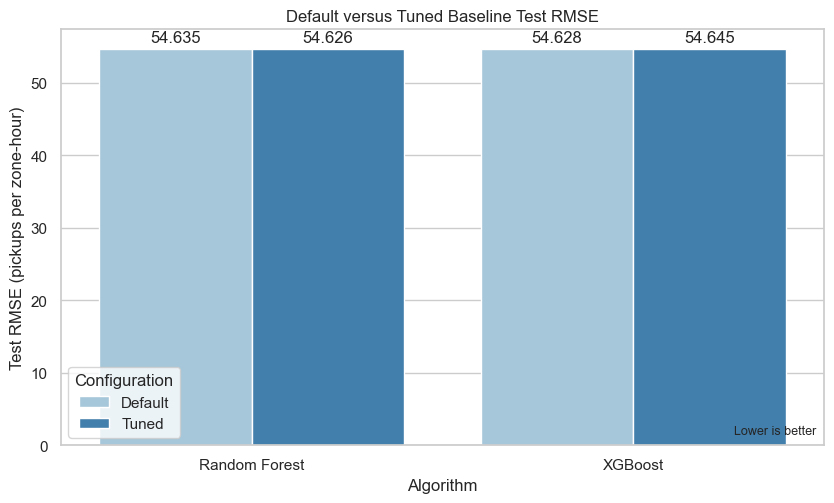

In [18]:
def plot_default_tuned_metric(metric, ylabel, title, lower_is_better=True):
    # Plot one metric on its own meaningful numerical scale.
    chart = test_metrics.copy()
    chart["Algorithm"] = chart["Model"].str.replace(" \\(Default\\)| \\(Tuned\\)", "", regex=True)
    chart["Configuration"] = np.where(chart["Model"].str.contains("Default"), "Default", "Tuned")

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    sns.barplot(data=chart, x="Algorithm", y=metric, hue="Configuration", palette=["#9ecae1", "#3182bd"], ax=ax)
    ax.set(title=title, xlabel="Algorithm", ylabel=ylabel)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

    direction = "Lower is better" if lower_is_better else "Higher is better"
    ax.text(0.99, 0.02, direction, transform=ax.transAxes, ha="right", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


# Display RMSE separately because it is the primary error metric.
plot_default_tuned_metric(
    metric="RMSE",
    ylabel="Test RMSE (pickups per zone-hour)",
    title="Default versus Tuned Baseline Test RMSE",
)


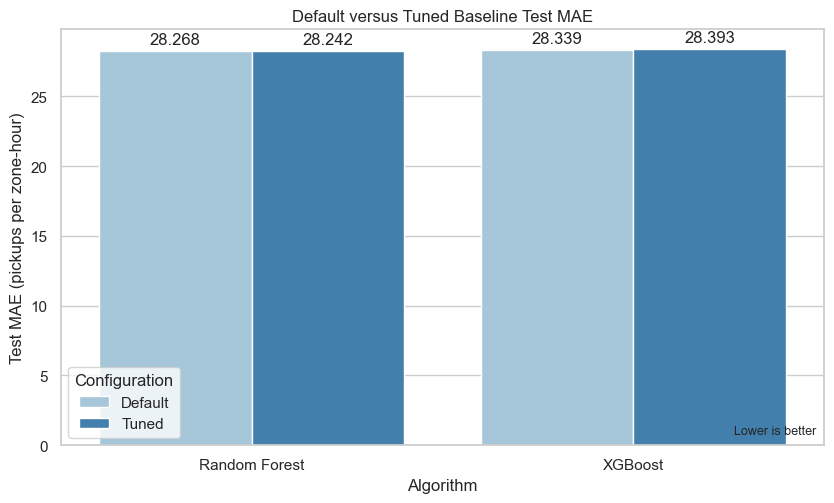

In [19]:
# Display MAE on its own scale.
plot_default_tuned_metric(
    metric="MAE",
    ylabel="Test MAE (pickups per zone-hour)",
    title="Default versus Tuned Baseline Test MAE",
)


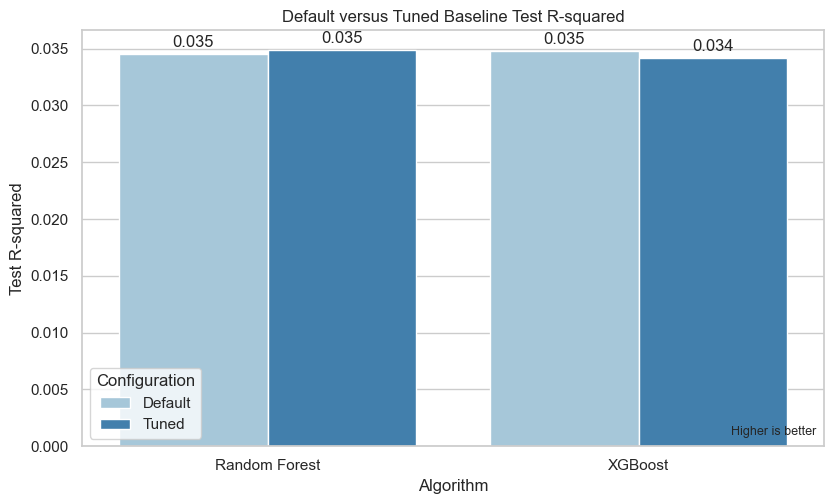

In [20]:
# Display R-squared separately because higher values are better.
plot_default_tuned_metric(
    metric="R2",
    ylabel="Test R-squared",
    title="Default versus Tuned Baseline Test R-squared",
    lower_is_better=False,
)


## 9. Permutation feature importance of the tuned baseline models

All five baseline predictors are included. Importance is measured as the increase in testing RMSE after one predictor is shuffled. Larger positive values indicate stronger reliance by the fitted model. Error bars show variation across repeated permutations.


In [21]:
# Calculate test permutation importance for both tuned models.
permutation_rows = []
for model_name in ["Random Forest (Tuned)", "XGBoost (Tuned)"]:
    result = permutation_importance(
        final_models[model_name],
        X_test,
        y_test,
        scoring="neg_root_mean_squared_error",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    for feature, mean_value, std_value in zip(
        BASELINE_FEATURES,
        result.importances_mean,
        result.importances_std,
    ):
        permutation_rows.append({
            "Model": model_name.replace(" (Tuned)", ""),
            "Feature": feature,
            "RMSE increase": mean_value,
            "Standard deviation": std_value,
        })

feature_importance = pd.DataFrame(permutation_rows)
display(feature_importance.sort_values(["Model", "RMSE increase"], ascending=[True, False]).round(4))


,Model,Feature,RMSE increase,Standard deviation
0,Random Forest,hour,1.8995,0.0370
1,Random Forest,day_of_week,0.4985,0.0180
3,Random Forest,temperature_f,0.0013,0.0008
4,Random Forest,precipitation_in,0.0007,0.0003
2,Random Forest,month,0.0000,0.0000
5,XGBoost,hour,1.7477,0.0324
6,XGBoost,day_of_week,0.3305,0.0117
9,XGBoost,precipitation_in,0.0146,0.0029
8,XGBoost,temperature_f,0.0076,0.0016
7,XGBoost,month,0.0000,0.0000


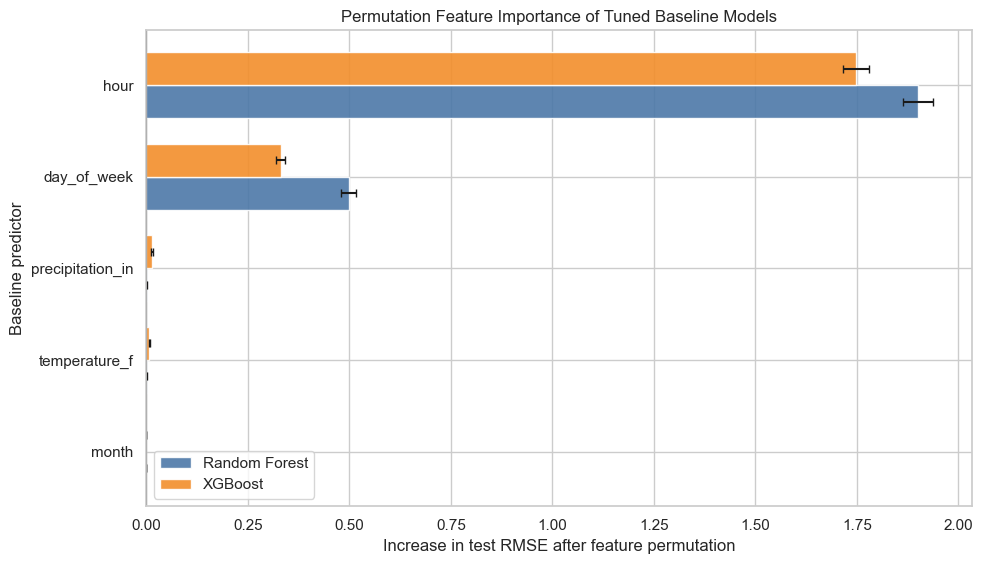

In [22]:
# Plot all baseline feature importances with repeated-permutation error bars.
feature_order = (
    feature_importance.groupby("Feature")["RMSE increase"]
    .mean()
    .sort_values(ascending=True)
    .index
    .tolist()
)
models = ["Random Forest", "XGBoost"]
y_positions = np.arange(len(feature_order))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(10, 5.8))
for offset, model_name, colour in [
    (-bar_height / 2, "Random Forest", "#4c78a8"),
    (bar_height / 2, "XGBoost", "#f28e2b"),
]:
    subset = feature_importance.set_index(["Model", "Feature"]).loc[model_name].loc[feature_order]
    ax.barh(
        y_positions + offset,
        subset["RMSE increase"],
        height=bar_height,
        xerr=subset["Standard deviation"],
        color=colour,
        alpha=0.9,
        capsize=3,
        label=model_name,
    )

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_positions)
ax.set_yticklabels(feature_order)
ax.set(
    title="Permutation Feature Importance of Tuned Baseline Models",
    xlabel="Increase in test RMSE after feature permutation",
    ylabel="Baseline predictor",
)
ax.legend()
plt.tight_layout()
plt.show()


## 10. Export reusable results

The saved files allow the later comparison notebook to evaluate baseline and enriched models without retraining them. Figures are intentionally not saved because they remain visible in this executed notebook.


In [23]:
# Save final models with clear names.
model_file_names = {
    "Random Forest (Default)": "baseline_default_random_forest.joblib",
    "Random Forest (Tuned)": "baseline_tuned_random_forest.joblib",
    "XGBoost (Default)": "baseline_default_xgboost.joblib",
    "XGBoost (Tuned)": "baseline_tuned_xgboost.joblib",
}
for model_name, file_name in model_file_names.items():
    joblib.dump(final_models[model_name], RESULTS_DIR / file_name)

# Save aligned test predictions with LocationID retained only as metadata.
test_predictions = test_df[METADATA_COLUMNS + [TARGET]].copy()
test_predictions = test_predictions.rename(columns={TARGET: "actual_pickups"})
for model_name, predictions in test_prediction_columns.items():
    column_name = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    test_predictions[column_name] = predictions

# Save metric, trial and interpretation tables.
default_validation_metrics.to_csv(RESULTS_DIR / "baseline_default_validation_metrics.csv", index=False)
selected_configuration_summary.to_csv(RESULTS_DIR / "baseline_selected_validation_summary.csv", index=False)
test_metrics.to_csv(RESULTS_DIR / "baseline_default_vs_tuned_test_metrics.csv", index=False)
test_improvements.to_csv(RESULTS_DIR / "baseline_tuning_improvements.csv", index=False)
rf_trials.to_csv(RESULTS_DIR / "baseline_random_forest_bayesian_trials.csv", index=False)
xgb_trials.to_csv(RESULTS_DIR / "baseline_xgboost_bayesian_trials.csv", index=False)
rf_parameter_importance.assign(Algorithm="Random Forest").to_csv(
    RESULTS_DIR / "baseline_random_forest_hyperparameter_importance.csv", index=False
)
xgb_parameter_importance.assign(Algorithm="XGBoost").to_csv(
    RESULTS_DIR / "baseline_xgboost_hyperparameter_importance.csv", index=False
)
feature_importance.to_csv(RESULTS_DIR / "baseline_permutation_feature_importance.csv", index=False)
test_predictions.to_csv(RESULTS_DIR / "baseline_test_predictions.csv", index=False)

selected_parameters = {
    "Random Forest": rf_study["best_parameters"],
    "XGBoost": xgb_study["best_parameters"],
}
with open(RESULTS_DIR / "baseline_selected_hyperparameters.json", "w", encoding="utf-8") as file:
    json.dump(selected_parameters, file, indent=2)

saved_outputs = sorted(path.name for path in RESULTS_DIR.iterdir())
print(f"Saved {len(saved_outputs)} baseline result files:")
for file_name in saved_outputs:
    print("-", file_name)


Saved 15 baseline result files:
- baseline_default_random_forest.joblib
- baseline_default_validation_metrics.csv
- baseline_default_vs_tuned_test_metrics.csv
- baseline_default_xgboost.joblib
- baseline_permutation_feature_importance.csv
- baseline_random_forest_bayesian_trials.csv
- baseline_random_forest_hyperparameter_importance.csv
- baseline_selected_hyperparameters.json
- baseline_selected_validation_summary.csv
- baseline_test_predictions.csv
- baseline_tuned_random_forest.joblib
- baseline_tuned_xgboost.joblib
- baseline_tuning_improvements.csv
- baseline_xgboost_bayesian_trials.csv
- baseline_xgboost_hyperparameter_importance.csv


## 11. Completion statement

The notebook has now established default baseline performance, selected tuned configurations using validation RMSE, evaluated all four final models on the untouched testing partition, interpreted the tuned models using all baseline features, and exported the reusable evidence required by the final comparison notebook.
